### Regresión Lineal: Ejemplo
##### Queremos predecir el precio de una casa usando su tamaño en m², # de habitaciones y # de parqueaderos.
- Casas más grandes tienden a costar más.
- Queremos que el modelo aprenda esta relación automáticamente.

- La ecuación del modelo será: Precio=β0​+β1​(Tamano)+β2​(Habitaciones)+β3​(Parqueaderos)

In [ ]:
# DESCRIPCIÓN DEL DATASET

import pandas as pd

# Cargar dataset
df = pd.read_csv("datasetcasas.csv")
# Ver dimensiones (300, 4)
print(df.shape)
print()
# Ver primeras filas
print(df.head())
print()
# Información general
print(df.info())
print()
# Estadísticas
print(df.describe())
# count (variables no nulas)
# mean (promedio)
# std (desviación estándar)
# min (minimo)
# 25,50,75 (Q1, media, Q3)
# max (maximo)

(300, 4)

   Tamano_m2  Habitaciones  Parqueaderos  Precio
0        162             2             1  263318
1        152             1             1  209344
2         74             4             2  198057
3        166             2             0  237162
4        131             3             0  214190

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Tamano_m2     300 non-null    int64
 1   Habitaciones  300 non-null    int64
 2   Parqueaderos  300 non-null    int64
 3   Precio        300 non-null    int64
dtypes: int64(4)
memory usage: 9.5 KB
None

        Tamano_m2  Habitaciones  Parqueaderos         Precio
count  300.000000    300.000000    300.000000     300.000000
mean   131.770000      3.143333      1.006667  235809.916667
std     41.144054      1.466273      0.805472   58522.342738
min     60.000000      1.000000      0.000000  103446.000000
25%    

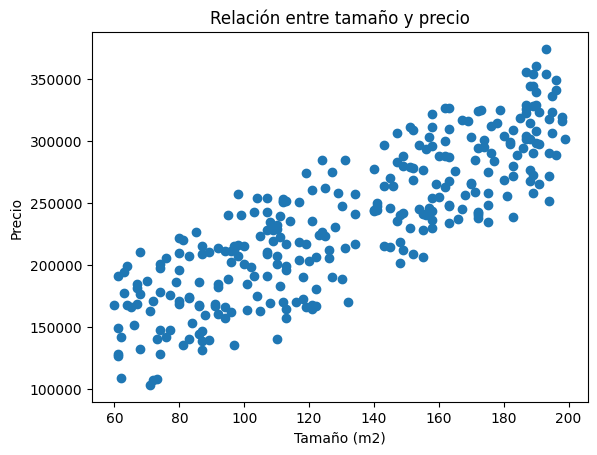

In [26]:
# VISUALIZACIÓN DE LA RELACION ENTRE VARIABLES

# Este codigo nos ayuda a ver como se encuentran distribuidos los datos en el plano cartesiano

import matplotlib.pyplot as plt

plt.scatter(df["Tamano_m2"], df["Precio"])

plt.xlabel("Tamaño (m2)")
plt.ylabel("Precio")
plt.title("Relación entre tamaño y precio")

plt.show()

###### tenemos un patrón lineal positivo, recomendable para regresión lineal
###### el tamaño de la casa es proporcional a su precio, habitaciones, parqueaderos

In [ ]:
# instalar la librería "scikit-learn" si no tienen instalado (ejecutar el codigo de abajo)
# scikit-learn es una biblioteca de código abierto para aprendizaje automático (Machine Learning) en Python
# scikit-learn Sirve para realizar tareas de clasificación, regresión, clustering y reducción de dimensionalidad

# !pip install scikit-learn


In [29]:
# DIVISION DEL DATA SET
# El conjunto de datos se divide en "train" (para entrenar el modelo) y "test" (para probar el modelo)
# preparación típica se hace de 80-20: 80% de los datos para entrenamiento y 20% para prueba

from sklearn.model_selection import train_test_split

# SEPARACIÓN DE LAS VARIABLES x(variables predictoras/independientes), y(variables objetivo y/ dependientes)
X = df[["Tamano_m2", "Habitaciones", "Parqueaderos"]]

y = df["Precio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para test
    random_state=42     # reproducibilidad
)

print("Datos entrenamiento:", X_train.shape)
print("Datos prueba:", X_test.shape)


Datos entrenamiento: (240, 3)
Datos prueba: (60, 3)


In [50]:
# Entrenamiento del modelo 

from sklearn.linear_model import LinearRegression

# Crea el modelo
modelo = LinearRegression()

# Entrenar modelo
# el metodo .fit() hace que el modelo aprenda la mejor linea recta que minimiza el error entre: precios reales y precios predichos
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


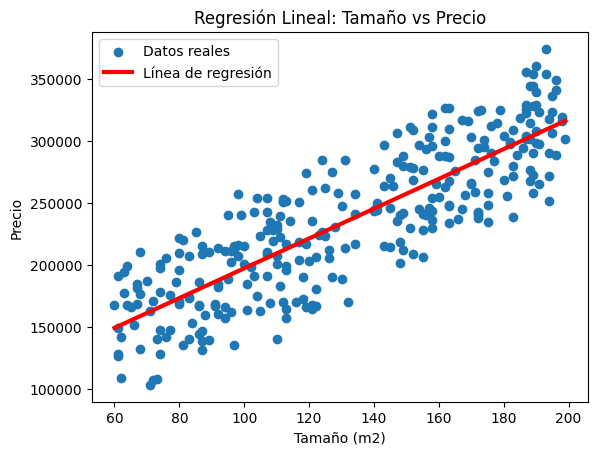

In [ ]:
# Promedios de las otras variables
habitaciones_prom = df["Habitaciones"].mean()
parqueaderos_prom = df["Parqueaderos"].mean()

# Valores para la línea
x_linea = np.linspace(df["Tamano_m2"].min(), df["Tamano_m2"].max(), 100)

# Predicción usando el modelo completo
y_linea = (
    modelo.intercept_
    + modelo.coef_[0] * x_linea
    + modelo.coef_[1] * habitaciones_prom
    + modelo.coef_[2] * parqueaderos_prom
)

# Gráfico
plt.scatter(df["Tamano_m2"], df["Precio"], label="Datos reales")

plt.plot(x_linea, y_linea, color="red", linewidth=3, label="Línea de regresión")

plt.xlabel("Tamaño (m2)")
plt.ylabel("Precio")
plt.title("Regresión Lineal: Tamaño vs Precio")

plt.legend()
plt.show()

In [54]:
# Parámetros del modelo
# Intercepto: Es el valor base del precio cuando todas las variables son cero.
# Coeficientes (pendientes): Indican cuánto cambia el precio cuando una variable aumenta en una unidad.

pendiente = modelo.coef_[0]
intercepto = modelo.intercept_

print("Pendiente:", pendiente)
print("Intercepto:", intercepto)
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})
print("\nCoeficientes del modelo:")
print(coeficientes)

Pendiente: 1202.2417986467585
Intercepto: 1246.7776278161327

Coeficientes del modelo:
       Variable   Coeficiente
0     Tamano_m2   1202.241799
1  Habitaciones  19616.614124
2  Parqueaderos  14285.584353


###### Cada metro cuadrado adicional aumenta el precio aproximadamente $1202.
######

In [55]:
# PREDICCIÓN DEL MODELO
# Predicciones
y_pred = modelo.predict(X_test)

# Comparar valores reales vs predichos
resultados = pd.DataFrame({
    "Precio_real": y_test,
    "Precio_predicho": y_pred
})

print(resultados.head())

     Precio_real  Precio_predicho
203       253981    256540.889407
266       212315    206248.056857
152       290869    287320.319943
9         283569    270728.362877
233       207598    206628.802203


In [56]:
# EVALUAMOS EL MODELO

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2:", r2)
print("MAE:", mae)
print("MSE:", mse)

R2: 0.987418674785239
MAE: 4788.655224831781
MSE: 35932676.09691708
